<a href="https://colab.research.google.com/github/aaishwarymishra/attention-is-all-you-need/blob/main/Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Positinal Encoding

## Positional Encoding Formula

- ### PE<sub>(pos,2i)</sub> = sin(pos/10000<sup>2i/dim_model</sup>)
- ### PE<sub>(pos,2i+1)</sub> = cos(pos/10000<sup>2i/dim_model</sup>)

### where

- i is i<sup>th</sup> dim from 0-(dim_model/2 - 1)
- pos is index from 0-(seq_length-1)
- dim_model is dimenstion of the model

### Example:

for i = 0,pos=0

2i=0,
2i+1=1

- PE<sub>(0,0)</sub> = sin(0/10000<sup>0/dim_model</sup>)
- PE<sub>(0,1)</sub> = cos(0/10000<sup>0/dim_model</sup>)



In [1]:
import numpy as np
import tensorflow as tf

def positional_encoding(length,depth):
  '''
  Args:
  length: sequence length
  depth: embedding dim or depth
  '''

  # 2i/dim_model can be written as 2i/2*mid_dim_model giving i/mid_dim_model
  depth = depth/2

  positions = np.arange(length).reshape((-1,1)) # (seq,1)
  # i/mid_dim_model
  depths  = np.arange(depth).reshape((1,-1))/depth # (1,depth)

  angle_rates = 1/(10000**depths) # (1,depth)

  angle_rads = positions*angle_rates # (seq,depth)

  pos_encoding = np.concat([
      np.sin(angle_rads),
      np.cos(angle_rads)
  ],axis=-1)

  return tf.constant(pos_encoding,dtype=tf.float32)

In [2]:
val = positional_encoding(100,512)
val.shape

TensorShape([100, 512])

(2048, 512)


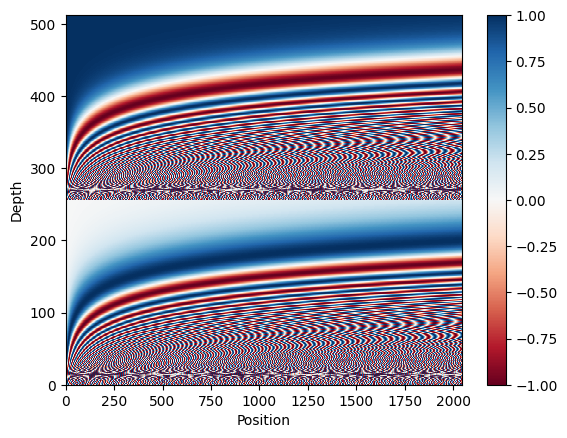

In [3]:
import matplotlib.pyplot as plt

pos_encoding = positional_encoding(length=2048, depth=512)

# Check the shape.
print(pos_encoding.shape)

# Plot the dimensions.
plt.pcolormesh(pos_encoding.numpy().T, cmap='RdBu')
plt.ylabel('Depth')
plt.xlabel('Position')
plt.colorbar()
plt.show()

In [4]:
class PositionalEmbedding(tf.keras.layers.Layer):
  def __init__(self,vocab_size,d_model) -> None:
    super().__init__()
    self.d_model = d_model
    self.embedding = tf.keras.layers.Embedding(vocab_size,d_model)
    self.pos_encoding = positional_encoding(length=2048,depth=d_model)

  def call(self,x):
    length = tf.shape(x)[-1]
    x = self.embedding(x)
    x*= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
    x+= self.pos_encoding[tf.newaxis, :length, :]
    return x

In [5]:
p_encoder = PositionalEmbedding(100,128)

(1, 100)


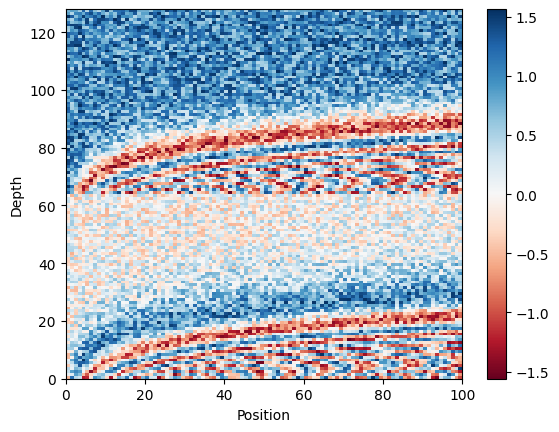

In [6]:
import numpy as np

sample1 = np.random.randint(low=0, high=100, size=(1, 100))
sample2 = np.random.randint(low=0, high=100, size=(1, 150))
print(sample1.shape)
pos_encoded_sample1=p_encoder(sample1)
pos_encoded_sample2=p_encoder(sample2)
plt.pcolormesh(pos_encoded_sample1.numpy()[0,:,:].T, cmap='RdBu')
plt.ylabel('Depth')
plt.xlabel('Position')
plt.colorbar()
plt.show()

# Attention

In [7]:
def create_mask(dim1,dim2):
  mask = 1-np.tril(np.ones((dim1,dim2)))
  return tf.constant(mask.reshape(1,1,dim1,dim2),dtype=tf.float32)

In [8]:
  def create_causal_mask(dim1,dim2):
    mask = 1 - tf.linalg.band_part(tf.ones((dim1, dim2)), -1, 0)
    return tf.reshape(mask, (1, 1, dim1, dim2))

In [9]:
create_mask(5,5)

<tf.Tensor: shape=(1, 1, 5, 5), dtype=float32, numpy=
array([[[[0., 1., 1., 1., 1.],
         [0., 0., 1., 1., 1.],
         [0., 0., 0., 1., 1.],
         [0., 0., 0., 0., 1.],
         [0., 0., 0., 0., 0.]]]], dtype=float32)>

In [10]:
class MultiHeadAttention(tf.keras.layers.Layer):
  def __init__(self,num_heads,key_dim) -> None:
    super().__init__()
    assert key_dim%num_heads == 0
    self.dim = key_dim
    self.head = num_heads
    self.dim_head = key_dim//num_heads
    self.wq = tf.keras.layers.Dense(key_dim)
    self.wk = tf.keras.layers.Dense(key_dim)
    self.wv = tf.keras.layers.Dense(key_dim)
    self.final = tf.keras.layers.Dense(key_dim)

  def create_causal_mask(self,dim1,dim2):
    mask = 1 - tf.linalg.band_part(tf.ones((dim1, dim2)), -1, 0)
    return tf.reshape(mask, (1, 1, dim1, dim2))

  def split_heads(self,x,batch_size):
    x = tf.reshape(x,(batch_size,-1,self.head,self.dim_head))
    return tf.transpose(x,perm=[0,2,1,3])

  def call(self,query,key,value,mask=False):
    batch_size = tf.shape(query)[0]

    query = self.wq(query)
    value = self.wv(value)
    key = self.wk(key)

    # Gives shape (batch,heads,seq,dim_head)
    query = self.split_heads(query,batch_size)
    key = self.split_heads(key,batch_size)
    value = self.split_heads(value,batch_size)

    # (batch,heads,seq,seq)
    attention_scores = tf.matmul(query,tf.transpose(key,perm=[0,1,3,2]))
    attention_scores = attention_scores/tf.math.sqrt(tf.cast(self.dim_head,dtype=tf.float32))

    if mask:
      mask = self.create_causal_mask(tf.shape(attention_scores)[-2],tf.shape(attention_scores)[-1])
      attention_scores += mask*(-1e9)

    attention_weights = tf.nn.softmax(attention_scores,axis=-1)

    # (batch,heads,seq,dim_head)
    context_vector = tf.matmul(attention_weights,value)

    # (batch,seq,heads,seq_dim)
    context_vector = tf.transpose(context_vector,perm=[0,2,1,3])

    # (batch,seq,dim)
    return self.final(tf.reshape(context_vector,(batch_size,-1,self.dim)))


In [11]:
class BaseAttention(tf.keras.layers.Layer):
  def __init__(self,**kwargs):
    super().__init__()
    self.mha = MultiHeadAttention(**kwargs)
    self.norm = tf.keras.layers.LayerNormalization()
    self.add = tf.keras.layers.Add()

In [12]:
class CrossAttention(BaseAttention):
  def __init__(self, **kwargs):
    super().__init__(**kwargs)

  def call(self,query,context):
    atten_output = self.mha(query=query,value=context,key=context)
    x = self.add([atten_output,query])
    x = self.norm(x)
    return x

In [13]:
sample_ca = CrossAttention(num_heads=2, key_dim=128)
print(pos_encoded_sample1.shape)
print(pos_encoded_sample2.shape)
print(sample_ca(pos_encoded_sample1, pos_encoded_sample2).shape)

(1, 100, 128)
(1, 150, 128)
(1, 100, 128)


In [14]:
class GlobalAttention(BaseAttention):
  def __init__(self, **kwargs):
    super().__init__(**kwargs)

  def call(self,context):
    atten_output = self.mha(key=context,value=context,query=context)
    x = self.add([atten_output,context])
    x = self.norm(x)
    return x

In [15]:
sample_ga = GlobalAttention(num_heads=2, key_dim=128)
print(pos_encoded_sample1.shape)
print(sample_ga(pos_encoded_sample1).shape)

(1, 100, 128)
(1, 100, 128)


In [16]:
class CausalAttention(BaseAttention):
  def __init__(self, **kwargs):
    super().__init__(**kwargs)

  def call(self,context):
    atten_output = self.mha(key=context,value=context,query=context,mask=True)
    x = self.add([atten_output,context])
    x = self.norm(x)
    return x

In [17]:
sample_ca = CausalAttention(num_heads=2, key_dim=128)
print(pos_encoded_sample2.shape)
print(sample_ca(pos_encoded_sample2).shape)

(1, 150, 128)
(1, 150, 128)


# Encoder and Decoder

### Model dim  and Feed forward units

In [18]:
d_model = 512
units = 1024

## Feed Forward

In [19]:
class FeedForward(tf.keras.layers.Layer):
  def __init__(self,d_model,units,drop_rate=0.2) -> None:
    super().__init__()
    self.layer = tf.keras.Sequential([
        tf.keras.layers.Dense(units,"relu"),
        tf.keras.layers.Dense(d_model),
        tf.keras.layers.Dropout(drop_rate)
    ])
    self.add = tf.keras.layers.Add()
    self.norm = tf.keras.layers.LayerNormalization()

  def call(self,x):

    output = self.layer(x)
    x = self.add([output,x])
    x = self.norm(x)
    return x


In [20]:
sample_feed_forward = FeedForward(128,2048)
print(pos_encoded_sample1.shape)
print(sample_feed_forward(pos_encoded_sample1).shape)

(1, 100, 128)
(1, 100, 128)


## Encoder

In [21]:
class EncodeLayer(tf.keras.layers.Layer):
  def __init__(self,d_model,num_heads,units,drop_rate=0.2) -> None:
    super().__init__()
    self.ga = GlobalAttention(num_heads=num_heads,key_dim=d_model)
    self.ff = FeedForward(d_model=d_model,units=units,drop_rate=drop_rate)

  def call(self,x):
    return self.ff(self.ga(x))


In [22]:
sample_encoder_layer = EncodeLayer(128,2,2048)
print(pos_encoded_sample1.shape)
print(sample_encoder_layer(pos_encoded_sample1).shape)

(1, 100, 128)
(1, 100, 128)


In [23]:
class Encoder(tf.keras.layers.Layer):
  def __init__(self,num_layers,vocab_size,d_model,num_heads,units,drop_rate=0.1) -> None:
    super().__init__()
    self.num_layers = num_layers
    self.d_model = d_model
    self.pe = PositionalEmbedding(vocab_size=vocab_size,d_model=d_model)
    self.dropout = tf.keras.layers.Dropout(drop_rate)

    layers = [EncodeLayer(num_heads=num_heads,units=units,d_model=d_model,drop_rate=drop_rate) for _ in range(num_layers)]

    self.enc_layers = tf.keras.Sequential(layers)

  def call(self,x):
    x = self.pe(x)

    x = self.dropout(x)

    return self.enc_layers(x)

In [24]:
sample_encoder = Encoder(num_layers=2,vocab_size=100,d_model=128,num_heads=2,units=2048)
encoded_sample = sample_encoder(sample1)
print(encoded_sample.shape)

(1, 100, 128)


## Decoder

In [25]:
class DecoderLayer(tf.keras.layers.Layer):
  def __init__(self,d_model,units,num_heads,drop_rate=0.2) -> None:
    super().__init__()
    self.ca = CrossAttention(num_heads=num_heads,key_dim=d_model)
    self.causal_atten = CausalAttention(num_heads=num_heads,key_dim=d_model)
    self.ff = FeedForward(d_model=d_model,units=units,drop_rate=drop_rate)

  def call(self,x,context):
    x = self.causal_atten(x)
    x = self.ca(query=x,context=context)
    return self.ff(x)

In [26]:
sample_decoder_layer = DecoderLayer(d_model=128,num_heads=2,units=2048)
decoded_sample = sample_decoder_layer(pos_encoded_sample2,encoded_sample)
print(decoded_sample.shape)

(1, 150, 128)


In [27]:
class Decoder(tf.keras.layers.Layer):
  def __init__(self,num_layers,vocab_size,d_model,units,num_heads,drop_rate=0.1) -> None:
    super().__init__()
    self.num_layers = num_layers
    self.d_model = d_model
    self.pe = PositionalEmbedding(vocab_size,d_model)
    self.dropout = tf.keras.layers.Dropout(drop_rate)

    self.layers = [DecoderLayer(d_model=d_model,units=units,num_heads=num_heads,drop_rate=drop_rate) for _ in range(num_layers)]

  def call(self,x,context):
    x = self.pe(x)
    x = self.dropout(x)

    for i in range(self.num_layers):
      x = self.layers[i](x,context)

    return x

In [28]:
sample_decoder = Decoder(num_layers=2,vocab_size=100,d_model=128,num_heads=2,units=2048)
decoded_sample = sample_decoder(sample2,encoded_sample)
print(decoded_sample.shape)

(1, 150, 128)


# Transformer

In [29]:
class Transformer(tf.keras.Model):
  def __init__(self,num_layers,heads,d_model,units,input_vocab,target_vocab,drop_rate=0.1) -> None:
    super().__init__()

    self.encoder = Encoder(num_layers=num_layers,vocab_size=input_vocab,d_model=d_model,num_heads=heads,units=units,drop_rate=drop_rate)
    self.decoder = Decoder(num_layers=num_layers,vocab_size=target_vocab,d_model=d_model,units=units,num_heads=heads,drop_rate=drop_rate)
    self.linear = tf.keras.layers.Dense(target_vocab)


  def call(self,inputs):
    context = inputs['input_ids']
    x = inputs['decoder_input_ids']
    context = self.encoder(context)
    x = self.decoder(x,context)
    return self.linear(x)

In [30]:
num_layers = 4
d_model = 128
dff = 512
num_heads = 8
dropout_rate = 0.1
input_vocab = 200
target_vocab = 200

In [31]:
sample_transformer = Transformer(num_layers=num_layers,heads=num_heads,d_model=d_model,units=dff,input_vocab=input_vocab,target_vocab=target_vocab,drop_rate=dropout_rate)

In [32]:
sample_transformer({'input_ids':sample1,'decoder_input_ids':sample2}).shape

TensorShape([1, 150, 200])

In [33]:
sample_transformer.summary()

Model: "transformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_1 (Encoder)             │ ?                      │       818,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_1 (Decoder)             │ ?                      │     1,083,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_126 (Dense)               │ (1, 150, 200)          │        25,800 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,928,392 (7.36 MB)

 Trainable params: 1,928,392 (7.36 MB)

 Non-trainable params: 0 (0.00 B)

# Data Preparation

In [34]:
import requests
import zipfile
from datasets import load_dataset
import pathlib

In [35]:
dataset_url = "https://www.kaggle.com/api/v1/datasets/download/vaibhavkumar11/hindi-english-parallel-corpus"
dataset_path = pathlib.Path("hindi-english-parallel-corpus")

try:
  if dataset_path.is_dir():
    print("Dataset already downloaded")
  else:
    dataset_path.mkdir(parents=True,exist_ok=True)
    response = requests.get(dataset_url)
    with open(dataset_path/"hindi-english-parallel-corpus.zip","wb") as f:
      f.write(response.content)
    with zipfile.ZipFile(dataset_path/"hindi-english-parallel-corpus.zip","r") as zip_ref:
      zip_ref.extractall(dataset_path)
except Exception as e:
  print(f"Exception {e} occured")

Dataset already downloaded


In [36]:
data = load_dataset("csv",data_files=str(dataset_path/"hindi_english_parallel.csv"),split='train[:100000]')

In [37]:
data[0]

{'hindi': 'अपने अनुप्रयोग को पहुंचनीयता व्यायाम का लाभ दें',
 'english': 'Give your application an accessibility workout'}

In [38]:
data = data.filter(lambda x: x['english'] and x['hindi'],batch_size=1000)

# Tokenizer

In [39]:
vocab_size = 32000

In [40]:
!pip install -q tokenizers

In [41]:
from tokenizers import models, Tokenizer, normalizers, pre_tokenizers, decoders, trainers, processors

In [42]:
tokenizer = Tokenizer(models.BPE(unk_token="[UNK]"))

In [43]:
# Normalization step
# tokenizer.normalizer = normalizers.BertNormalizer(lowercase=True)

In [44]:
# tokenizer.normalizer.normalize_str("Olá, tudo bem?")

In [45]:
tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)

In [46]:
tokenizer.pre_tokenizer.pre_tokenize_str("Olá, tudo bem?")

[('OlÃ¡', (0, 3)),
 (',', (3, 4)),
 ('Ġtudo', (4, 9)),
 ('Ġbem', (9, 13)),
 ('?', (13, 14))]

In [47]:
trainer = trainers.BpeTrainer(
    vocab_size=vocab_size, special_tokens=["[UNK]", "[START]", "[END]", "[PAD]", "[MASK]"]
)

In [48]:
def batch_iterator(dataset,batch_size=1000):
    for i in range(0, dataset.num_rows, batch_size):
        yield dataset[i : i + batch_size]["hindi"] + dataset[i : i + batch_size]["english"]

In [49]:
print(f"Tokenizer vocab before training {tokenizer.get_vocab_size()}")

Tokenizer vocab before training 0


In [50]:
tokenizer.train_from_iterator(batch_iterator(data),trainer=trainer)

In [51]:
print(f"Tokenizer vocab after training {tokenizer.get_vocab_size()}")

Tokenizer vocab after training 17783


In [52]:
tokenizer.encode("Let's test this tokenizer.").tokens

['Let', "'", 's', 'Ġtest', 'Ġthis', 'Ġtoken', 'izer', '.']

In [53]:
start_id = tokenizer.token_to_id('[START]')
end_id = tokenizer.token_to_id('[END]')

tokenizer.post_processor = processors.TemplateProcessing(
    single=f"[START]:0 $A:0 [END]:0",
    special_tokens=[('[START]',start_id),('[END]',end_id)]
)

# tokenizer.post_processor = processors.ByteLevel()

In [54]:
sentence = "Let's test this tokenizer."
encodings = tokenizer.encode(sentence)
print(encodings.tokens)
print(encodings.ids)
print(encodings.type_ids)
start, end = encodings.offsets[3]
print(sentence[start:end])

['[START]', 'Let', "'", 's', 'Ġtest', 'Ġthis', 'Ġtoken', 'izer', '.', '[END]']
[1, 8195, 11, 87, 4891, 428, 3317, 3873, 18, 2]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
s


In [55]:
tokenizer.decoder = decoders.ByteLevel()
tokenizer.save("tokenizer.json")
tokenizer.decode(encodings.ids)

"Let's test this tokenizer."

In [56]:
from transformers import PreTrainedTokenizerFast

fast_tokenizer = PreTrainedTokenizerFast(
    tokenizer_object=tokenizer,
    bos_token="[START]",
    eos_token="[END]",
    unk_token="[UNK]",
    pad_token="[PAD]",
    mask_token="[MASK]",
)

In [57]:
eng,hin = data[0]['english'],data[0]['hindi']
print(eng)
print(hin)

Give your application an accessibility workout
अपने अनुप्रयोग को पहुंचनीयता व्यायाम का लाभ दें


In [58]:
eng_tokenized = fast_tokenizer(eng,padding=True,return_tensors='tf')
hindi_tokenized = fast_tokenizer(hin,padding=True,return_tensors='tf')

print(eng_tokenized['input_ids'])
print(hindi_tokenized['input_ids'])

print(fast_tokenizer.decode(eng_tokenized['input_ids'][0]))
print(fast_tokenizer.decode(hindi_tokenized['input_ids'][0]))

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


tf.Tensor([[    1  7509   533  1500   434  4209 11040     2]], shape=(1, 8), dtype=int32)
tf.Tensor(
[[   1 2120  166  439  204  181  164  412  173  201  170  173  643 1141
   538  174  579  163  251  164  177  163  177  163  189  170  163  226
   163  299  255  184    2]], shape=(1, 33), dtype=int32)
[START]Give your application an accessibility workout[END]
[START]अपने अनुप्रयोग को पहुंचनीयता व्यायाम का लाभ दें[END]


# Data preprocessing

In [59]:
def sequence_length(data):
  eng,hin = data['english'],data['hindi']
  eng_tokenized = fast_tokenizer(eng)
  hindi_tokenized = fast_tokenizer(hin)
  labels = hindi_tokenized['input_ids']
  input_ids = eng_tokenized['input_ids']
  return {'input_ids':input_ids,'labels':labels,'eng_len':len(input_ids),'hin_len':len(labels)}

In [60]:
tokenized_data = data.map(sequence_length)
tokenized_data = tokenized_data.remove_columns(['english','hindi'])

English Mean: 7.38040683189418
Hindi Mean: 19.190778743884014


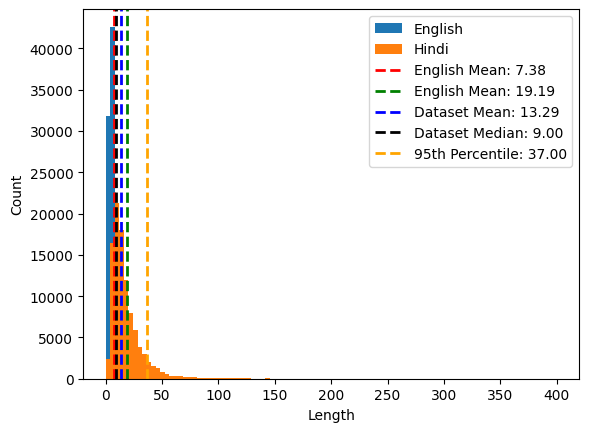

In [61]:
import matplotlib.pyplot as plt
import numpy as np

eng_len_list = tokenized_data['eng_len'][:]
hin_len_list = tokenized_data['hin_len'][:]

eng_len_mean = np.mean(eng_len_list)
hin_len_mean = np.mean(hin_len_list)
dataset_mean = np.mean(eng_len_list+hin_len_list)
dataset_median = np.median(eng_len_list+hin_len_list)
max_len_95th = np.percentile(eng_len_list+hin_len_list,95)

print(f"English Mean: {eng_len_mean}")
print(f"Hindi Mean: {hin_len_mean}")

bins = np.linspace(0,400,100)
plt.hist(eng_len_list,bins=bins,label="English")
plt.hist(hin_len_list,bins=bins,label="Hindi")
plt.axvline(eng_len_mean, color='red', linestyle='dashed', linewidth=2, label=f'English Mean: {eng_len_mean:.2f}')
plt.axvline(hin_len_mean, color='green', linestyle='dashed', linewidth=2, label=f'English Mean: {hin_len_mean:.2f}')
plt.axvline(dataset_mean, color='blue', linestyle='dashed', linewidth=2, label=f'Dataset Mean: {dataset_mean:.2f}')
plt.axvline(dataset_median, color='black', linestyle='dashed', linewidth=2, label=f'Dataset Median: {dataset_median:.2f}')
plt.axvline(max_len_95th, color='orange', linestyle='dashed', linewidth=2, label=f'95th Percentile: {max_len_95th:.2f}')
plt.xlabel("Length")
plt.ylabel("Count")
plt.legend()
plt.show()

In [62]:
from transformers import DataCollatorForSeq2Seq
# set padding = "max_length" for fixed sized padding but you have to perform truncation before or it will give error
collator = DataCollatorForSeq2Seq(tokenizer=fast_tokenizer,return_tensors='tf',padding=True,max_length=max_len_95th.astype(int),pad_to_multiple_of=8,label_pad_token_id=fast_tokenizer.pad_token_id)

class CustomCollator:
  def __init__(self,collator):
    self.collator = collator

  def __call__(self,data):
    result = self.collator(data)
    result['decoder_input_ids'] = result['labels'][:,:-1]
    result['labels'] = result['labels'][:,1:]
    return result

custom_collator = CustomCollator(collator)


In [63]:
# max_length = max_len_95th.astype(int)
# def data_tokenization(data):
#   eng,hin = data['english'],data['hindi']
#   eng_tokenized = fast_tokenizer(eng,truncation=True,max_length=max_length,padding='max_length',return_tensors='np')
#   hindi_tokenized = fast_tokenizer(hin,truncation=True,max_length=max_length,padding='max_length',return_tensors='np')

#   # Process each sequence in the batch
#   input_ids = eng_tokenized['input_ids']
#   labels = hindi_tokenized['input_ids']
#   decoder_input_ids = hindi_tokenized['input_ids'][:,:-1]
#   labels = hindi_tokenized['input_ids'][:,1:]


#   return {'input_ids':input_ids,'labels':labels,'decoder_input_ids':decoder_input_ids}

In [64]:
# tokenized_data = data.map(data_tokenization,batched=True)

In [65]:
tokenized_data = tokenized_data.remove_columns(['eng_len','hin_len'])
tokenized_data = tokenized_data.train_test_split(test_size=0.2)
temp = tokenized_data['test'].train_test_split(test_size=0.5)
tokenized_data['validation'] = temp.pop('train')
tokenized_data['test'] = temp.pop('test')

In [66]:
train = tokenized_data['train'].to_tf_dataset(
    columns=['input_ids','decoder_input_ids'],
    label_cols='labels',
    collate_fn=custom_collator,
    shuffle=True,
    batch_size=32,
).cache().prefetch(tf.data.AUTOTUNE)

validation = tokenized_data['validation'].to_tf_dataset(
    columns=['input_ids','decoder_input_ids'],
    label_cols='labels',
    collate_fn=custom_collator,
    shuffle=False,
    batch_size=32,
).cache().prefetch(tf.data.AUTOTUNE)

test = tokenized_data['test'].to_tf_dataset(
    columns=['input_ids','decoder_input_ids'],
    label_cols='labels',
    collate_fn=custom_collator,
    shuffle=False,
    batch_size=32,
).cache().prefetch(tf.data.AUTOTUNE)

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2751: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


In [67]:
fast_tokenizer.pad_token

'[PAD]'

# Hyper Parameters

In [68]:
d_model = 256
units = 512
vocab_size = fast_tokenizer.vocab_size
num_layers = 2
heads = 2
pad_token_id = fast_tokenizer.pad_token_id

# Training

## Custom secheduler

### Formula for learning rate

lr = d_model<sup>-0.5</sup> * min(step<sup>-0.5</sup>,step*warmup<sup>-1.5</sup>)

In [69]:
import tensorflow as tf

class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
  def __init__(self,d_model,warmup_steps=4000):
    super().__init__()
    self.d_model = tf.cast(d_model,tf.float32)
    self.warmup_steps = warmup_steps

  def __call__(self,step):
    step = tf.cast(step, dtype=tf.float32)
    arg1 = tf.math.rsqrt(step)
    arg2 = step * (self.warmup_steps ** -1.5)
    return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1,arg2)

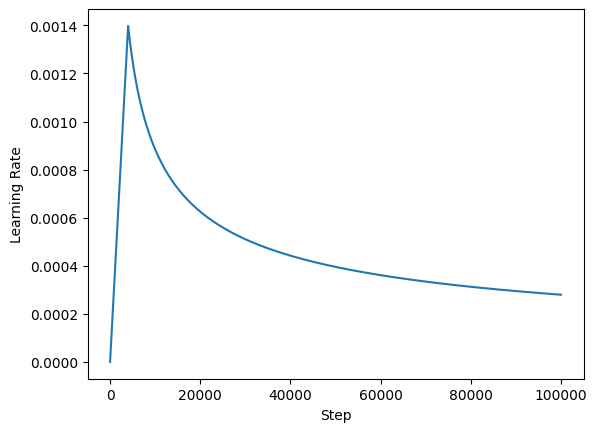

In [70]:
sample_schedule = CustomSchedule(d_model=128)
returned_lr = tf.range(100000,dtype=tf.float32)
plt.plot(returned_lr,sample_schedule(returned_lr))
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.show()

### Custom loss and Acuracy

In [71]:
from tensorflow.keras.losses import Loss
from tensorflow.keras.metrics import Metric
class MaskedCategoricalCrossEntropy(Loss):
  def __init__(self,pad_token_id=0,name='masked_categorical_crossentropy'):
    super().__init__(name=name)
    self.pad_token_id = pad_token_id

  def call(self,y_true,y_pred):
    mask = tf.math.not_equal(y_true,self.pad_token_id)
    loss = tf.keras.losses.sparse_categorical_crossentropy(y_true,y_pred,from_logits=True)
    mask = tf.cast(mask,dtype=loss.dtype)
    loss = loss * mask
    return tf.reduce_sum(loss)/tf.reduce_sum(mask)


class MaskedAccuaracy(Metric):
  def __init__(self,pad_token_id=0,name='masked_accuracy'):
    super().__init__(name=name)
    self.pad_token_id = pad_token_id
    self.total_matches = self.add_weight(name="total_matches",initializer="zeros")
    self.total_count = self.add_weight(name="total_words",initializer="zeros")

  def update_state(self,y_true,y_pred, sample_weight=None):
    mask = tf.math.not_equal(y_true,self.pad_token_id)
    pred = tf.argmax(y_pred,axis=-1)
    match = tf.cast(tf.math.equal(y_true,pred),dtype=tf.float32)
    match = match * tf.cast(mask,dtype=match.dtype)
    self.total_matches.assign_add(tf.reduce_sum(match))
    self.total_count.assign_add(tf.reduce_sum(tf.cast(mask,dtype=tf.float32)))

  def result(self):
    return self.total_matches/self.total_count

  def reset_state(self):
    self.total_matches.assign(0)
    self.total_count.assign(0)

### Training phase

In [72]:
from tensorflow.keras.optimizers import AdamW

scheduler = CustomSchedule(d_model=d_model)
optimizer = AdamW(scheduler,weight_decay=0.01)
loss = MaskedCategoricalCrossEntropy(pad_token_id=pad_token_id)
accuracy = MaskedAccuaracy(pad_token_id=pad_token_id)

In [83]:
from tensorflow.keras import mixed_precision

# Mixed precision
# mixed_precision.set_global_policy('mixed_float16')


model = Transformer(d_model=d_model,num_layers=num_layers,heads=heads,units=units,input_vocab=vocab_size,target_vocab=vocab_size)

Model: "transformer_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_4 (Encoder)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_4 (Decoder)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_225 (Dense)               │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [84]:
sample,_ = next(iter(train))
print(model.predict(sample).shape)
model.summary()

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
(32, 39, 17783)


Model: "transformer_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_4 (Encoder)             │ ?                      │     5,606,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_4 (Decoder)             │ ?                      │     6,134,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_225 (Dense)               │ (32, 39, 17783)        │     4,570,231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,310,903 (62.22 MB)

 Trainable params: 16,310,903 (62.22 MB)

 Non-trainable params: 0 (0.00 B)

In [74]:
model.compile(optimizer=optimizer,loss=loss,metrics=[accuracy])

In [75]:
from huggingface_hub import notebook_login,push_to_hub_keras
notebook_login()

In [76]:
from transformers.keras_callbacks import PushToHubCallback
from tensorflow.keras.callbacks import EarlyStopping
push_callback = PushToHubCallback(output_dir="transformer-translation",hub_model_id="Blankyy/attention-is-all-you-need")
earlystopping_callback = EarlyStopping(monitor='val_loss',patience=3)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_deprecation.py:131: FutureWarning: 'Repository' (from 'huggingface_hub.repository') is deprecated and will be removed from version '1.0'. Please prefer the http-based alternatives instead. Given its large adoption in legacy code, the complete removal is only planned on next major release.
For more details, please read https://huggingface.co/docs/huggingface_hub/concepts/git_vs_http.
  warnings.warn(warning_message, FutureWarning)
/content/transformer-translation is already a clone of https://huggingface.co/Blankyy/attention-is-all-you-need. Make sure you pull the latest changes with `repo.git_pull()`.


In [77]:
model.fit(train,validation_data=validation,epochs=50,callbacks=[push_callback,earlystopping_callback])

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2751: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


   8/2499 ━━━━━━━━━━━━━━━━━━━━ 8:28:42 12s/step - loss: 9.7972 - masked_accuracy: 0.0000e+00

KeyboardInterrupt: 